# Classical and modified Williamson–Hall

This notebook applies the staged Dippa workflow to all nine nickel samples: rough-start peak re-fit, integral breadth, nearest-position instrumental subtraction, and then classical/mwhA/mwhB/mwhC fitting. HKLs are assigned explicitly; nothing auto-indexes the peaks.

The Nickel material inputs come from the stored WH result/preferences: $q_{edge}=1.515$,
$q_{screw}=2.333$, and $C_{h00}=0.284$. They are passed explicitly to the generic
fitter rather than installed as global defaults.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np

from dippa import (
    Phase,
    Reflection,
    bind_reflections,
    delta_k,
    fit_williamson_hall,
    format_hkil,
    load_matlab_samples,
)
from dippa.background import fit_background_quadratic
from dippa.fitting import fit_pattern

DATA_PATH = Path("../data/ni_combo.mat")
SAMPLES = load_matlab_samples(DATA_PATH)
PHASE = Phase("FCC", a=3.53)
HKL = [
    Reflection(1, 1, 1),
    Reflection(2, 0, 0),
    Reflection(2, 2, 0),
    Reflection(3, 1, 1),
    Reflection(2, 2, 2),
]
HKL_LABELS = [format_hkil(reflection, PHASE.cstruct) for reflection in HKL]
CH00 = float(np.mean([0.289, 0.279]))
Q_EDGE, Q_SCREW = 1.515, 2.333
Q_BOUNDS = (Q_EDGE, Q_SCREW)


def rough_start(sample, seed):
    x, y = sample.data[:, 0], sample.data[:, 1]
    aa = sample.aa.copy()
    rng = np.random.default_rng(seed)
    for peak in range(sample.n_peaks):
        aa[0, peak] += rng.uniform(-0.005, 0.005)
        aa[1, peak] *= rng.uniform(0.5, 1.5)
        aa[2, peak] = aa[4, peak] = 0.002
        aa[3, peak] = aa[5, peak] = 0.5
    aa[:3, -1] = fit_background_quadratic(
        x, y, aa[0, :sample.n_peaks], half_width=0.02
    )
    return aa


print(f"Loaded {len(SAMPLES)} samples; explicit reflections: {', '.join(HKL_LABELS)}")
print(f"Nickel GUI-preset ch00 = mean(0.289, 0.279) = {CH00:.6f}")
print(f"Nickel q bounds: edge={Q_EDGE}, screw={Q_SCREW}")


Loaded 9 samples; explicit reflections: (111), (200), (220), (311), (222)
Nickel GUI-preset ch00 = mean(0.289, 0.279) = 0.284000
Nickel q bounds: edge=1.515, screw=2.333


## Peak re-fit and instrumental subtraction

Integral breadth is used throughout. Flagged peak fits are excluded by default. Nonpositive sample-minus-instrument breadths are dropped with an explicit warning and retained in each result's exclusion report.


In [2]:
PEAK_FITS = []
CORRECTIONS = []
BINDINGS = []
for sample_index, sample in enumerate(SAMPLES):
    peak_fit = fit_pattern(
        sample.data[:, 0],
        sample.data[:, 1],
        rough_start(sample, seed=42 + sample_index),
        half_width=0.02,
        tube="Co",
        n_passes=3,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        correction = delta_k(
            peak_fit, sample.aa_I, kind="IB", drop_nonpositive=True, include_flagged=True
        )
    PEAK_FITS.append(peak_fit)
    CORRECTIONS.append(correction)
    BINDINGS.append(
        bind_reflections(peak_fit.aa[0, :-1], PHASE, HKL, tol=0.001)
    )

print(f"{'sample':<18} {'retained':>8}  exclusions")
print("-" * 80)
for sample, correction in zip(SAMPLES, CORRECTIONS):
    excluded = [
        f"{HKL_LABELS[item.peak_index]}: {', '.join(item.reasons)}"
        for item in correction.excluded_peaks
    ]
    print(f"{sample.name:<18} {len(correction.delta_k):>8}  {excluded or 'none'}")


sample             retained  exclusions
--------------------------------------------------------------------------------
niHmid_halfpc             4  ['(111): nonpositive delta_k']
niE_mid_12pc              5  none
niF_mid_4pc               5  none
niC_24pc                  5  none
niB_mid_3pc               5  none
niD_mid_17pc              5  none
ni_new_10pc               5  none
ni_30pc_allp              5  none
ni2pc_new                 5  none


## Four model forms on one sample

Every parameter and interval printed below comes from the result object. Classical WH
uses its default equal-$H^2$ family presentation (111/222); pass
`classical_mode="all"` for the optional all-peak regression. With only five
reflections, modified fits have two degrees of freedom, so their low-DoF warnings
are expected and material to interpretation. Fit curves use a dense grid from zero
to $1.2\max(X)$ rather than merely joining fitted data points.


sample: ni_new_10pc
variant    q [95% CI]                         screw fraction  size [95% CI]                          strain [95% CI]
----------------------------------------------------------------------------------------------------------------------------------
classical  0 [0, 0]             nan  -7.51591e-05 [nan, nan]  0.00171835 [nan, nan]
  n=2, DoF=0, warnings=('low degrees of freedom: 0; confidence intervals are fragile',)
mwhA       1.91918 [1.57081, 2.26756]           0.494  -7.851e-05 [-0.000273001, 0.000115981]  0.00286549 [0.00230194, 0.00342904]
  n=5, DoF=2, warnings=('low degrees of freedom: 2; confidence intervals are fragile',)
mwhB       1.95256 [1.36634, 2.53879]           0.535  -2.35197e-05 [-0.00399186, 0.00394482]  0.00264115 [0.00219867, 0.00308363]
  n=5, DoF=2, warnings=('low degrees of freedom: 2; confidence intervals are fragile',)
mwhC       1.86574 [1.34897, 2.38252]           0.429  0.000290983 [0.00010845, 0.000473517]  0.00494117 [0.00333993, 0.00

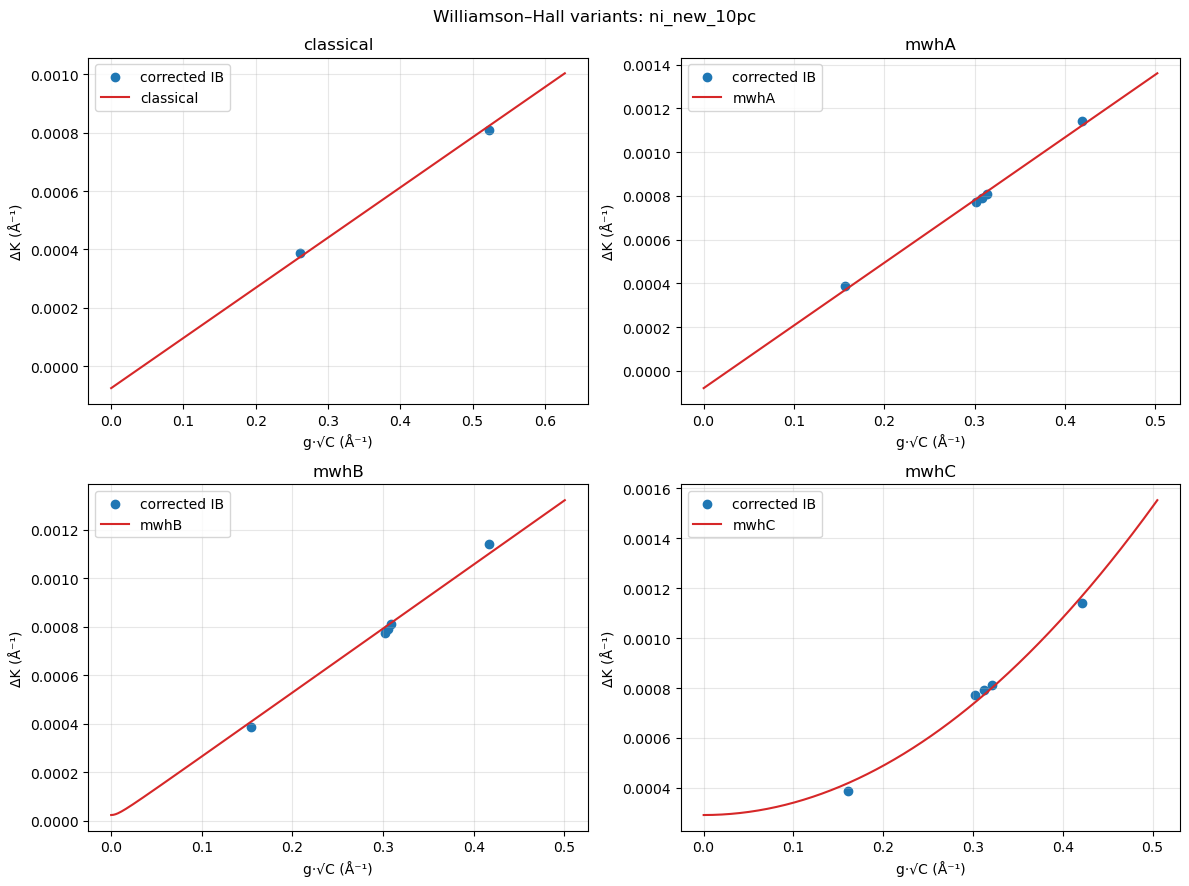

In [3]:
DEMO_INDEX = next(i for i, sample in enumerate(SAMPLES) if sample.name == "ni_new_10pc")
VARIANTS = ["classical", "mwhA", "mwhB", "mwhC"]
VARIANT_RESULTS = {
    variant: fit_williamson_hall(
        CORRECTIONS[DEMO_INDEX], BINDINGS[DEMO_INDEX], CH00,
        variant=variant, q_bounds=Q_BOUNDS,
    )
    for variant in VARIANTS
}

def curve_on_x(result, x):
    p = result.parameters
    if result.variant in {"classical", "mwhA"}:
        return p.size + p.strain * x
    if result.variant == "mwhB":
        return np.sqrt(p.size**2 + p.strain**2 * x**2)
    return p.size + p.strain * x**2

print(f"sample: {SAMPLES[DEMO_INDEX].name}")
print(f"{'variant':<10} {'q [95% CI]':<34} {'screw fraction':>14}  {'size [95% CI]':<38} {'strain [95% CI]'}")
print("-" * 130)
for variant, result in VARIANT_RESULTS.items():
    p, ci = result.parameters, result.confidence_intervals
    print(
        f"{variant:<10} {p.q:.6g} [{ci.q[0]:.6g}, {ci.q[1]:.6g}]  "
        f"{result.screw_fraction if result.screw_fraction is not None else float('nan'):>14.3f}  "
        f"{p.size:.6g} [{ci.size[0]:.6g}, {ci.size[1]:.6g}]  "
        f"{p.strain:.6g} [{ci.strain[0]:.6g}, {ci.strain[1]:.6g}]"
    )
    print(f"  n={result.n_points}, DoF={result.dof}, warnings={result.warnings or 'none'}")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (variant, result) in zip(axes.flat, VARIANT_RESULTS.items()):
    x_grid = np.linspace(0.0, 1.2 * result.x.max(), 400)
    observed_delta_k = result.fitted_delta_k - result.residuals
    ax.scatter(result.x, observed_delta_k, label="corrected IB")
    ax.plot(x_grid, curve_on_x(result, x_grid), color="tab:red", label=variant)
    ax.set_title(variant)
    ax.set_xlabel("g·√C (Å⁻¹)")
    ax.set_ylabel("ΔK (Å⁻¹)")
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle(f"Williamson–Hall variants: {SAMPLES[DEMO_INDEX].name}")
plt.tight_layout()
plt.show()


## mwhA across the strain series

This walkthrough sets `include_flagged=True`, so bound-flagged peak fits remain in
the sensitivity series by explicit choice; nonpositive corrected breadths are still
dropped. Trends use Jacobian-based 95% confidence intervals, and the warnings in
each result remain part of the interpretation.


sample             strain axis q [95% CI]                         screw fraction  size [95% CI]                          strain [95% CI]
--------------------------------------------------------------------------------------------------------------------------------------------
niHmid_halfpc           83.409 2.31145 [-8.29807, 12.921]           0.974  -0.000999999 [-0.0255776, 0.0235776]  0.00556875 [-0.0643662, 0.0755037]
niE_mid_12pc           363.470 1.8046 [0.424697, 3.18451]           0.354  0.000119594 [-0.000701373, 0.000940561]  0.00321123 [0.000827109, 0.00559536]
niF_mid_4pc            200.665 2.16378 [-1.13091, 5.45846]           0.793  7.92211e-05 [-0.000968176, 0.00112662]  0.00146365 [-0.0015672, 0.00449449]
niC_24pc               489.184 1.51505 [-3.14517, 6.17527]           0.000  0.000436914 [-0.00241061, 0.00328444]  0.00373769 [-0.00457713, 0.0120525]
niB_mid_3pc            184.029 1.53656 [-11.8974, 14.9706]           0.026  0.000547243 [-1.34196e-05, 0.00110791]  0.

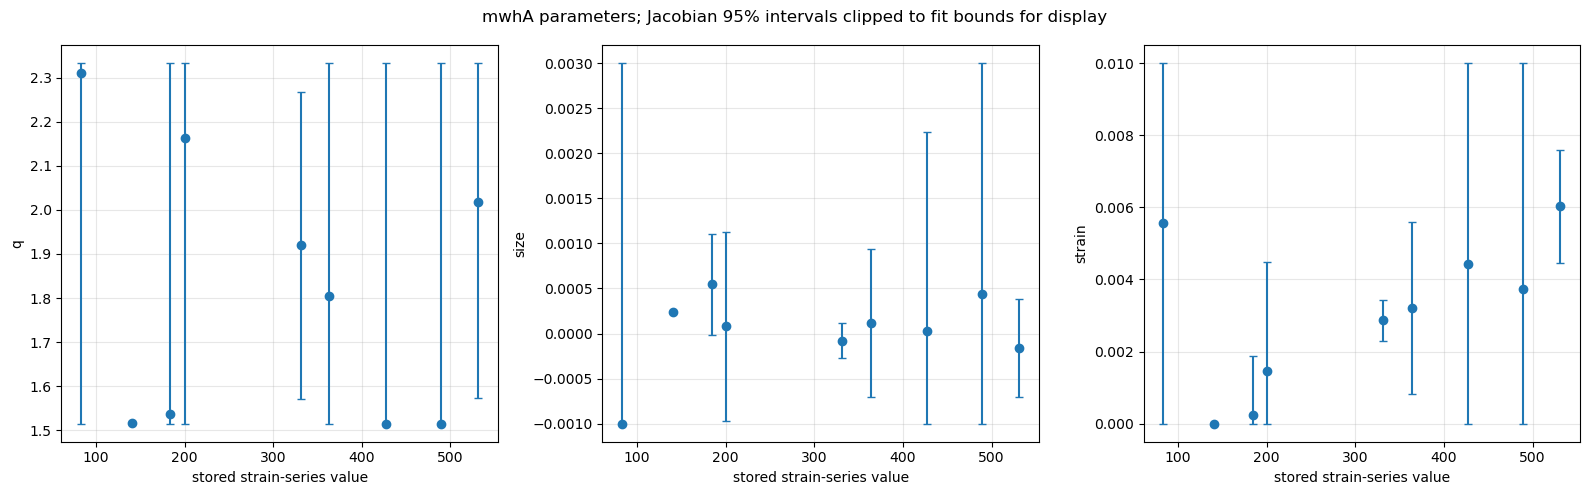

In [4]:
SERIES_RESULTS = []
for sample, correction, binding in zip(SAMPLES, CORRECTIONS, BINDINGS):
    result = (
        fit_williamson_hall(
            correction, binding, CH00, variant="mwhA", q_bounds=Q_BOUNDS
        )
        if len(correction.delta_k) >= 3
        else None
    )
    SERIES_RESULTS.append(result)

print(f"{'sample':<18} {'strain axis':>11} {'q [95% CI]':<34} {'screw fraction':>14}  {'size [95% CI]':<38} strain [95% CI]")
print("-" * 140)
for sample, correction, result in zip(SAMPLES, CORRECTIONS, SERIES_RESULTS):
    if result is None:
        print(f"{sample.name:<18} {sample.valstrain:>11.3f} not fit: {len(correction.delta_k)} retained points")
        continue
    p, ci = result.parameters, result.confidence_intervals
    print(
        f"{sample.name:<18} {sample.valstrain:>11.3f} "
        f"{p.q:.6g} [{ci.q[0]:.6g}, {ci.q[1]:.6g}]  "
        f"{result.screw_fraction:>14.3f}  "
        f"{p.size:.6g} [{ci.size[0]:.6g}, {ci.size[1]:.6g}]  "
        f"{p.strain:.6g} [{ci.strain[0]:.6g}, {ci.strain[1]:.6g}]"
    )

valid = [(sample, result) for sample, result in zip(SAMPLES, SERIES_RESULTS) if result]
axis_values = np.array([sample.valstrain for sample, _ in valid])
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_bounds = {"q": Q_BOUNDS, "size": (-0.001, 0.003), "strain": (0.0, 0.01)}
for ax, name in zip(axes, ["q", "size", "strain"]):
    estimates = np.array([getattr(result.parameters, name) for _, result in valid])
    intervals = np.array([getattr(result.confidence_intervals, name) for _, result in valid])
    display_intervals = np.clip(intervals, *plot_bounds[name])
    errors = np.vstack((estimates - display_intervals[:, 0], display_intervals[:, 1] - estimates))
    ax.errorbar(axis_values, estimates, yerr=errors, fmt="o", capsize=3)
    ax.set_xlabel("stored strain-series value")
    ax.set_ylabel(name)
    ax.grid(alpha=0.3)
fig.suptitle("mwhA parameters; Jacobian 95% intervals clipped to fit bounds for display")
plt.tight_layout()
plt.show()
